#### Steps::
##### 1. Reddit filter (Top vote, Most recent) [OUD/Veteran]
##### 2. Posts' categorize by size [small (10-50 words), medium (51-200 words), large (201-500 words)]
##### 3. Posts' mental status  classification (Classify by mentalRoBERTa) 
##### 4. Post and Comment classify by emotional category (Google's go-emotion data)
##### 5. Posts’ dissimilarity among each mental-class (Contextual dissimilarity)
##### 6. De-Identify Post and Comment


Saved workflow image: D:\Sajjad-Workspace\diversity-aware-reddit-sampling\reddit_data_process\reddit_data_pipline_workflow.png


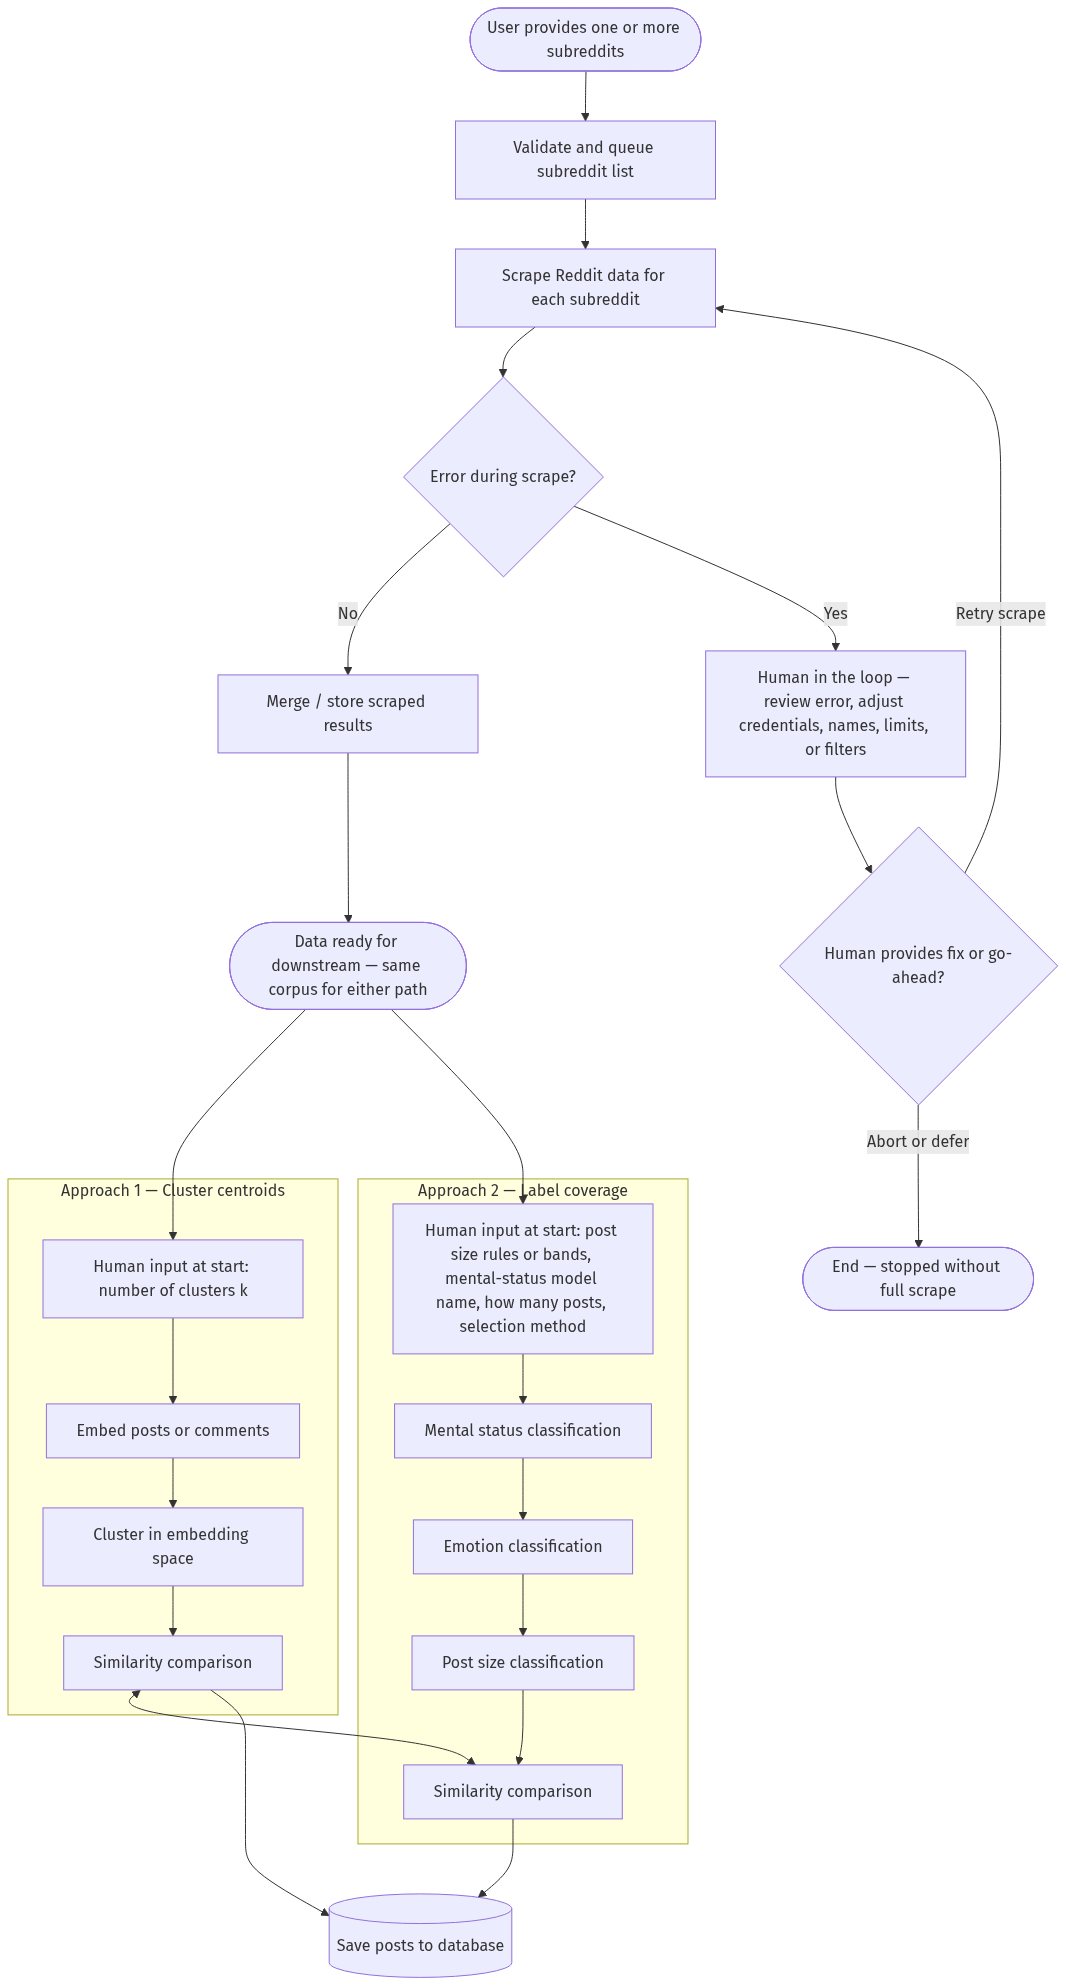

In [5]:
from IPython.display import display, Image
import base64
from pathlib import Path
import urllib.request

_UA = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
)
_PNG_MAGIC = b"\x89PNG\r\n\x1a\n"


def _workflow_png_bytes(mermaid: str) -> bytes:
    """mermaid.ink often 403s bare urllib; try browser UA then Kroki POST."""
    m = mermaid.strip()
    b64 = base64.urlsafe_b64encode(m.encode("utf-8")).decode("ascii").rstrip("=")
    ink_req = urllib.request.Request(
        f"https://mermaid.ink/img/{b64}",
        headers={"User-Agent": _UA},
    )
    try:
        with urllib.request.urlopen(ink_req, timeout=120) as resp:
            data = resp.read()
        if data.startswith(_PNG_MAGIC):
            return data
    except Exception:
        pass
    kroki_req = urllib.request.Request(
        "https://kroki.io/mermaid/png",
        data=m.encode("utf-8"),
        method="POST",
        headers={
            "User-Agent": _UA,
            "Content-Type": "text/plain; charset=utf-8",
        },
    )
    with urllib.request.urlopen(kroki_req, timeout=120) as resp:
        return resp.read()


_PNG_MERMAID = """
flowchart TD
    A([User provides one or more subreddits]) --> B[Validate and queue subreddit list]
    B --> C[Scrape Reddit data for each subreddit]
    C --> D{Error during scrape?}
    D -->|No| E[Merge / store scraped results]
    E --> Z([Data ready for downstream — same corpus for either path])
    D -->|Yes| F["Human in the loop — review error, adjust credentials, names, limits, or filters"]
    F --> G{Human provides fix or go-ahead?}
    G -->|Retry scrape| C
    G -->|Abort or defer| H([End — stopped without full scrape])

    subgraph APP1["Approach 1 — Cluster centroids"]
        I1["Human input at start: number of clusters k"]
        I1 --> U1[Embed posts or comments]
        U1 --> U2[Cluster in embedding space]
        U2 --> SC1[Similarity comparison]
    end

    subgraph APP2["Approach 2 — Label coverage"]
        I2["Human input at start: post size rules or bands, mental-status model name, how many posts, selection method"]
        I2 --> V1[Mental status classification]
        V1 --> V2[Emotion classification]
        V2 --> V3[Post size classification]
        V3 --> SC2[Similarity comparison]
    end

    SC1 <--> SC2

    Z --> I1
    Z --> I2
    SC1 --> DB[(Save posts to database)]
    SC2 --> DB
"""
try:
    png_bytes = _workflow_png_bytes(_PNG_MERMAID)
    if not png_bytes.startswith(_PNG_MAGIC):
        raise ValueError("Response was not a PNG (check network or diagram syntax).")
    _name = "reddit_data_pipline_workflow.png"
    _repo_sub = Path.cwd() / "reddit_data_proces"
    workflow_png = (_repo_sub / _name) if _repo_sub.is_dir() else (Path.cwd() / _name)
    workflow_png.write_bytes(png_bytes)
    print("Saved workflow image:", workflow_png.resolve())
    display(Image(data=png_bytes, format="png", width=820))
except Exception as e:
    print("PNG preview / save skipped:", e)


In [3]:
import praw
import pandas as pd
import time
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

# Read variables
client_id = os.getenv('REDDIT_CLIENT_ID')
client_secret = os.getenv('REDDIT_CLIENT_SECRET')
user_agent = os.getenv('REDDIT_USER_AGENT')
username = os.getenv('REDDIT_USERNAME')
password = os.getenv('REDDIT_PASSWORD')

In [3]:
# Initialize PRAW with env variables
reddit = praw.Reddit(
    client_id=client_id,
    client_secret=client_secret,
    user_agent=user_agent,
    username=username,
    password=password
)

# Verify the connection
try:
    user = reddit.user.me()
    if user:
        print(f"Authenticated as: {user}")
    else:
        print("Authentication failed. Please check your credentials.")
except Exception as e:
    print(f"An error occurred: {e}")

Authenticated as: Sajjad_Islam


In [ ]:
# Access the subreddit
subreddit = reddit.subreddit('OpiatesRecovery')

# Function to fetch comments based on the provided method
def get_comments(submission, comment_sort='top', limit=3):
    submission.comment_sort = comment_sort
    submission.comments.replace_more(limit=0)
    comments = submission.comments[:limit]
    if not comments:
        return [{
            'comment_author': '',
            'comment_body': '',
            'comment_ups': '',
            'comment_downs': '',
            'comment_score': ''
        }]
    return [{
        'comment_author': comment.author.name if comment.author else '[deleted]',
        'comment_body': comment.body,
        'comment_ups': comment.ups,
        'comment_downs': comment.downs,  # Not directly available, calculated from score
        'comment_score': comment.score
    } for comment in comments]

# Function to fetch posts and save to CSV
def fetch_and_save_posts(after=None, limit=100, comment_sort='top', comments_limit=3, filename='reddit_posts_and_comments.csv'):
    posts_data = []
    
    #submissions = list(subreddit.top(limit=limit, params={'after': after}))
    #submissions = list(subreddit.rising(limit=limit, params={'after': after}))
    submissions = list(subreddit.hot(limit=limit, params={'after': after}))
    for submission in submissions:
        post_info = {
            'title': submission.title,
            'post_author': submission.author.name if submission.author else '[deleted]',
            'selftext': submission.selftext,  # Post content
            'score': submission.score,
            'ups': submission.ups,
            'downs': submission.downs,  # Not directly available, calculated from score
            'url': submission.url,
            'comments': get_comments(submission, comment_sort=comment_sort, limit=comments_limit)
        }
        posts_data.append(post_info)
    
    # Create a DataFrame
    posts_df = pd.DataFrame(posts_data)
    
    if 'comments' in posts_df.columns:
        # Expand the comments column into separate rows
        expanded_comments = posts_df.explode('comments').reset_index(drop=True)

        # Normalize the nested comment dictionaries into separate columns
        comments_df = pd.json_normalize(expanded_comments['comments'])

        # Combine the posts and comments data
        combined_df = expanded_comments.drop(columns=['comments']).join(comments_df)
    else:
        combined_df = posts_df

    combined_df["data_source"] = "R-OpiatesRecovery"

    # Append to a CSV file
    if not os.path.isfile(filename):
        combined_df.to_csv(filename, index=False)
    else:
        combined_df.to_csv(filename, mode='a', header=False, index=False)

    print(f"Scraping complete for {limit} posts. Data saved to '{filename}'.")

    # Return the fullname of the last submission to use as 'after' in the next call
    return submissions[-1].fullname if submissions else None


In [ ]:
# Fetch top 1000 posts in batches of 100, with rate limiting
batch_size = 100
total_posts = 1000
after = None

for _ in range(0, total_posts, batch_size):
    after = fetch_and_save_posts(after=after, limit=batch_size, comment_sort='best', comments_limit=3, filename='reddit_hot_posts_and_best_comments_with_author.csv')
    print(f"Fetched {batch_size} posts. Waiting to avoid rate limit...")
    time.sleep(60)  # Pause to respect rate limits (adjust as needed)

print("All posts have been scraped and saved.")

Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments_with_author_2.csv'.
Fetched 100 posts. Waiting to avoid rate limit...
Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments_with_author_2.csv'.
Fetched 100 posts. Waiting to avoid rate limit...
Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments_with_author_2.csv'.
Fetched 100 posts. Waiting to avoid rate limit...
Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments_with_author_2.csv'.
Fetched 100 posts. Waiting to avoid rate limit...
Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments_with_author_2.csv'.
Fetched 100 posts. Waiting to avoid rate limit...
Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments_with_author_2.csv'.
Fetched 100 posts. Waiting to avoid rate limit...
Scraping complete for 100 posts. Data saved to 'reddit_hot_posts_and_best_comments

In [14]:
# DataFrame from scraped CSV (no API calls) — columns for analysis
csv_path = 'reddit_hot_posts_and_best_comments_with_author.csv'
if not os.path.isfile(csv_path):
    csv_path = os.path.join('reddit_data_proces', 'reddit_hot_posts_and_best_comments_with_author.csv')

KEEP_COLS = ['title', 'selftext', 'score', 'comment_body', 'comment_score']
df = pd.read_csv(csv_path, usecols=KEEP_COLS)
for c in ('score', 'comment_score'):
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"Loaded {len(df):,} rows, {len(KEEP_COLS)} columns from {csv_path}")
df.head(5)

Loaded 2,367 rows, 5 columns from reddit_hot_posts_and_best_comments_with_author.csv


,title,selftext,score,comment_body,comment_score
0,Sat/Sun March 21/22 check in,"Hey guys, hope your weekend’s going well! It’s...",2,I really appreciate the weekends. Went to yoga...,2.0
1,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",21,I really really wish Reddit would allow us to ...,5.0
2,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",21,"Hey Mike, I actually just got a message that I...",3.0
3,No WDs after 8 lo yrs of daily use… how? and b...,"hey guys,\n\nso I am using opioids since I’m 1...",5,"Je pense que si tu as eu de légers symptômes, ...",1.0
4,No WDs after 8 lo yrs of daily use… how? and b...,"hey guys,\n\nso I am using opioids since I’m 1...",5,Im hoping indont get any withdrawals from 2 we...,1.0


,n_rows,missing_raw,blank_or_whitespace,blank_pct,words_mean,words_std,words_median,chars_mean,chars_std,chars_median,chars_p90,chars_p99,chars_max
title,2367.0,0.0,0.0,0.00,6.80,4.60,5.0,37.39,24.58,29.0,70.0,124.0,136.0
selftext,2367.0,70.0,70.0,2.96,207.94,286.05,142.0,1117.37,1691.70,742.0,2139.4,7291.0,31408.0
comment_body,2367.0,108.0,108.0,4.56,73.09,89.89,44.0,387.47,478.36,235.0,899.8,2313.0,5178.0


,score,comment_score
count,2367.000,2259.000
mean,8.823,4.784
std,12.836,6.634
min,0.000,-1.000
5%,1.000,1.000
25%,2.000,2.000
50%,5.000,3.000
75%,11.000,5.000
95%,29.000,15.100
max,192.000,86.000


,title_n_char,selftext_n_char,comment_body_n_char,score,comment_score
title_n_char,1.000,0.173,-0.033,0.113,0.105
selftext_n_char,0.173,1.000,0.046,0.053,-0.041
comment_body_n_char,-0.033,0.046,1.000,0.014,0.066
score,0.113,0.053,0.014,1.000,0.437
comment_score,0.105,-0.041,0.066,0.437,1.000


[deleted]    20
[removed]     6
Name: comment_body_markers, dtype: int64

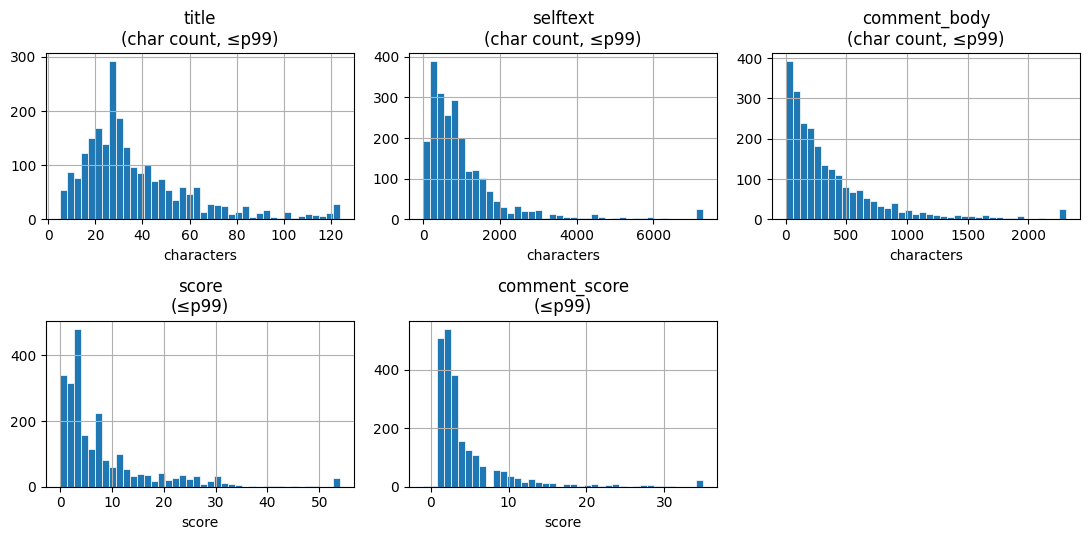

In [15]:
# Statistical analysis: text columns + post/comment scores
import matplotlib.pyplot as plt

TEXT_COLS = ['title', 'selftext', 'comment_body']
NUM_COLS = ['score', 'comment_score']


def as_text(series: pd.Series) -> pd.Series:
    return series.fillna('').astype(str)


def text_summary(df: pd.DataFrame, col: str) -> pd.Series:
    t = as_text(df[col])
    wc = t.str.split().str.len()
    cc = t.str.len()
    blank = t.str.strip().eq('')
    return pd.Series(
        {
            'n_rows': len(df),
            'missing_raw': df[col].isna().sum(),
            'blank_or_whitespace': int(blank.sum()),
            'blank_pct': 100.0 * blank.mean(),
            'words_mean': wc.mean(),
            'words_std': wc.std(),
            'words_median': wc.median(),
            'chars_mean': cc.mean(),
            'chars_std': cc.std(),
            'chars_median': cc.median(),
            'chars_p90': cc.quantile(0.9),
            'chars_p99': cc.quantile(0.99),
            'chars_max': cc.max(),
        }
    )


text_summary_df = pd.DataFrame({c: text_summary(df, c) for c in TEXT_COLS}).T
display(text_summary_df.round(2))

display(df[NUM_COLS].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3))

# Pearson: text lengths + scores (same row)
length_feats = {f'{c}_n_char': as_text(df[c]).str.len() for c in TEXT_COLS}
numeric_feats = {c: df[c] for c in NUM_COLS}
corr_df = pd.DataFrame({**length_feats, **numeric_feats})
display(corr_df.corr().round(3))

cb = as_text(df['comment_body']).str.lower()
display(
    pd.Series(
        {
            '[deleted]': cb.str.contains(r'\[deleted\]', regex=True).sum(),
            '[removed]': cb.str.contains(r'\[removed\]', regex=True).sum(),
        },
        name='comment_body_markers',
    )
)

# Histograms: text lengths (p99 clip) and scores (p99 clip)
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))
for i, col in enumerate(TEXT_COLS):
    ax = axes[0, i]
    cc = as_text(df[col]).str.len().astype(float)
    hi = float(cc.quantile(0.99))
    cc.clip(upper=hi).hist(bins=40, ax=ax, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col}\n(char count, ≤p99)')
    ax.set_xlabel('characters')

for j, col in enumerate(NUM_COLS):
    ax = axes[1, j]
    s = df[col].astype(float)
    hi = float(s.quantile(0.99))
    s.clip(upper=hi).hist(bins=40, ax=ax, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col}\n(≤p99)')
    ax.set_xlabel('score')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [16]:
# Post size category from combined title + selftext word count
# Small: 10–50 words | Medium: 51–200 | Large: 201–500 (<10 or >500 → missing)

_post_text = (
    df['title'].fillna('').astype(str).str.strip()
    + ' '
    + df['selftext'].fillna('').astype(str).str.strip()
).str.strip()

post_word_count = _post_text.str.split().str.len()

df['post_word_count'] = post_word_count
df['post_size_category'] = pd.Series(pd.NA, index=df.index, dtype='string')
df.loc[(post_word_count >= 10) & (post_word_count <= 50), 'post_size_category'] = 'small'
df.loc[(post_word_count >= 51) & (post_word_count <= 200), 'post_size_category'] = 'medium'
df.loc[(post_word_count >= 201) & (post_word_count <= 500), 'post_size_category'] = 'large'

df['post_size_category'] = df['post_size_category'].astype(
    pd.CategoricalDtype(categories=['small', 'medium', 'large'], ordered=True)
)

display(df['post_size_category'].value_counts(dropna=False))
df[['title', 'selftext', 'post_word_count', 'post_size_category']].head(10)


post_size_category
medium    1248
large      619
small      267
NaN        233
Name: count, dtype: int64

,title,selftext,post_word_count,post_size_category
0,Sat/Sun March 21/22 check in,"Hey guys, hope your weekend’s going well! It’s...",101,medium
1,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",248,large
2,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",248,large
3,No WDs after 8 lo yrs of daily use… how? and b...,"hey guys,\n\nso I am using opioids since I’m 1...",842,NaN
4,No WDs after 8 lo yrs of daily use… how? and b...,"hey guys,\n\nso I am using opioids since I’m 1...",842,NaN
5,No WDs after 8 lo yrs of daily use… how? and b...,"hey guys,\n\nso I am using opioids since I’m 1...",842,NaN
6,This God damn Dis-ease,"Why is this so hard? Tried tapering, tried CT ...",208,large
7,This God damn Dis-ease,"Why is this so hard? Tried tapering, tried CT ...",181,medium
8,Scared of withdrawal,Hey everyone so I have been on zoloft for a fe...,269,large
9,Scared of withdrawal,Hey everyone so I have been on zoloft for a fe...,269,large


In [17]:
# Category-wise size: counts, % of dataset, and word-count stats per category
_order = ['small', 'medium', 'large']
_labeled = df.dropna(subset=['post_size_category'])

category_wise_size = (
    _labeled.groupby('post_size_category', observed=True)['post_word_count']
    .agg(
        n_rows='count',
        words_min='min',
        words_max='max',
        words_mean='mean',
        words_median='median',
    )
    .reindex(_order)
)
category_wise_size['pct_of_all_rows'] = (100 * category_wise_size['n_rows'] / len(df)).round(2)

display(category_wise_size.round(3))

_n_out = df['post_size_category'].isna().sum()
print(
    f"Uncategorized (post word count <10 or >500): {_n_out} rows "
    f"({100 * _n_out / len(df):.2f}% of all rows)"
)


,n_rows,words_min,words_max,words_mean,words_median,pct_of_all_rows
post_size_category,,,,,,
small,267,10,50,35.472,38.0,11.28
medium,1248,51,200,120.446,117.0,52.72
large,619,201,497,298.097,281.0,26.15


Uncategorized (post word count <10 or >500): 233 rows (9.84% of all rows)


In [18]:
# Dataframe with only categorized posts (excludes rows outside 10–500 words)
df_categorized = df.loc[df['post_size_category'].notna()].copy()
print(f"df_categorized: {len(df_categorized):,} rows (from {len(df):,} total)")
df_categorized.head()

df_categorized: 2,134 rows (from 2,367 total)


,title,selftext,score,comment_body,comment_score,post_word_count,post_size_category
0,Sat/Sun March 21/22 check in,"Hey guys, hope your weekend’s going well! It’s...",2,I really appreciate the weekends. Went to yoga...,2.0,101,medium
1,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",21,I really really wish Reddit would allow us to ...,5.0,248,large
2,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",21,"Hey Mike, I actually just got a message that I...",3.0,248,large
6,This God damn Dis-ease,"Why is this so hard? Tried tapering, tried CT ...",2,NaN,NaN,208,large
7,This God damn Dis-ease,"Why is this so hard? Tried tapering, tried CT ...",1,NaN,NaN,181,medium


In [19]:
# Classify posts with multiMentalRoBERTA-6-class (6-way: Stress, Anxiety, Depression, PTSD, Suicidal, None)
# Model: https://huggingface.co/SajjadIslam/multiMentalRoBERTA-6-class
# Requires: pip install transformers torch
import torch
from transformers import pipeline

MULTIMENTAL_MODEL = 'SajjadIslam/multiMentalRoBERTA-6-class'
_device = 0 if torch.cuda.is_available() else -1

_multimental_clf = pipeline(
    'text-classification',
    model=MULTIMENTAL_MODEL,
    tokenizer=MULTIMENTAL_MODEL,
    truncation=True,
    max_length=512,
    device=_device,
)

_post_texts = (
    df_categorized['title'].fillna('').astype(str).str.strip()
    + ' '
    + df_categorized['selftext'].fillna('').astype(str).str.strip()
).str.strip()
_post_texts = _post_texts.mask(_post_texts.eq(''), '[no text]')

_preds = _multimental_clf(_post_texts.tolist(), batch_size=16)

df_categorized['mental_health_class'] = [p['label'] for p in _preds]
display(df_categorized['mental_health_class'].value_counts())
df_categorized[['title', 'post_size_category', 'mental_health_class']].head(8)


c:\Users\nipua\AppData\Local\anaconda3\envs\py312_gpu_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nipua\AppData\Local\anaconda3\envs\py312_gpu_2\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nipua\.cache\huggingface\hub\models--SajjadIslam--multiMentalRoBERTA-6-class. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to 

mental_health_class
depression    1858
suicide        117
none            53
ptsd            43
anxiety         40
stress          23
Name: count, dtype: int64

,title,post_size_category,mental_health_class
0,Sat/Sun March 21/22 check in,medium,depression
1,❣️Reminder to keep us safe:,large,depression
2,❣️Reminder to keep us safe:,large,depression
6,This God damn Dis-ease,large,depression
7,This God damn Dis-ease,medium,depression
8,Scared of withdrawal,large,depression
9,Scared of withdrawal,large,depression
10,Scared of withdrawal,large,depression


In [ ]:
# Save categorized + classified posts to CSV
_categorized_csv = 'reddit_posts_categorized_mental_status.csv'
df_categorized["data_source"] = "R-OpiatesRecovery"
df_categorized.to_csv(_categorized_csv, index=False, encoding='utf-8')
print(f"Saved {len(df_categorized):,} rows → {_categorized_csv}")


Saved 2,134 rows → reddit_posts_categorized_mental_status.csv


In [43]:
# GoEmotions: highest-confidence emotion for post (title + selftext) and for comment_body
# Same model / batch pattern as emotion_classification.ipynb (tasinhoque/roberta-large-go-emotions)
import os

os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

_EMOTION_MODEL = 'tasinhoque/roberta-large-go-emotions'
_emotion_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_emotion_tokenizer = AutoTokenizer.from_pretrained(_EMOTION_MODEL)
_emotion_model = AutoModelForSequenceClassification.from_pretrained(_EMOTION_MODEL).to(_emotion_device).eval()
_id2label = {int(k): v for k, v in _emotion_model.config.id2label.items()}


def _predict_top_emotion_labels(texts, batch_size: int = 8):
    """One label per text = argmax softmax probability (GoEmotions mult-class head)."""
    labels_out = []
    for i in tqdm(range(0, len(texts), batch_size), desc='GoEmotions'):
        batch = texts[i : i + batch_size]
        enc = _emotion_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt',
        ).to(_emotion_device)
        with torch.no_grad():
            logits = _emotion_model(**enc).logits
        top_ix = torch.argmax(torch.softmax(logits, dim=-1), dim=-1).cpu().tolist()
        labels_out.extend(_id2label[int(j)] for j in top_ix)
    return labels_out


_post_emotion_text = (
    df_categorized['title'].fillna('').astype(str).str.strip()
    + ' '
    + df_categorized['selftext'].fillna('').astype(str).str.strip()
).str.strip()
_post_emotion_text = _post_emotion_text.mask(_post_emotion_text.eq(''), '[no text]')

_comment_emotion_text = df_categorized['comment_body'].fillna('').astype(str).str.strip()
_comment_emotion_text = _comment_emotion_text.mask(_comment_emotion_text.eq(''), '[no text]')

df_categorized['post_emotion'] = _predict_top_emotion_labels(_post_emotion_text.tolist(), batch_size=8)
df_categorized['comment_emotion'] = _predict_top_emotion_labels(_comment_emotion_text.tolist(), batch_size=8)

display(df_categorized['post_emotion'].value_counts().head(12))
display(df_categorized['comment_emotion'].value_counts().head(12))
df_categorized[['title', 'comment_body', 'post_emotion', 'comment_emotion']].head(6)


GoEmotions: 100%|██████████| 267/267 [01:09<00:00,  3.82it/s]


post_emotion
curiosity         586
gratitude         299
optimism          213
fear              168
confusion         121
disappointment     95
joy                86
annoyance          78
neutral            72
sadness            66
amusement          46
caring             41
Name: count, dtype: int64

comment_emotion
neutral           453
caring            430
optimism          168
approval          167
admiration        151
curiosity         124
gratitude         120
annoyance          70
joy                69
amusement          51
sadness            42
disappointment     35
Name: count, dtype: int64

,title,comment_body,post_emotion,comment_emotion
0,Sat/Sun March 21/22 check in,I really appreciate the weekends. Went to yoga...,optimism,gratitude
1,❣️Reminder to keep us safe:,I really really wish Reddit would allow us to ...,gratitude,desire
2,❣️Reminder to keep us safe:,"Hey Mike, I actually just got a message that I...",gratitude,neutral
6,This God damn Dis-ease,NaN,gratitude,neutral
7,This God damn Dis-ease,NaN,gratitude,neutral
8,Scared of withdrawal,Sounds like opiates isn’t really the problem. ...,gratitude,neutral


In [44]:
# Save df_categorized to CSV (mental_health_class + post_emotion + comment_emotion + all other columns)
_categorized_csv = 'reddit_posts_categorized_mental_status_with_emotion.csv'
df_categorized["data_source"] = "R-OpiatesRecovery"
df_categorized.to_csv(_categorized_csv, index=False, encoding='utf-8')
print(f"Saved {len(df_categorized):,} rows → {_categorized_csv}")


Saved 2,134 rows → reddit_posts_categorized_mental_status_with_emotion.csv


In [45]:
df_categorized.sample(5)

,title,selftext,score,comment_body,comment_score,post_word_count,post_size_category,mental_health_class,post_emotion,comment_emotion
1455,Do SNRIs help Tramadol Withdrawal?,I've been taking a small dose of tramadol for ...,5,For tramadol I used L-Tryptophan andL-Tyrosine...,2.0,47,small,depression,curiosity,approval
1144,anyone else constantly feel like there’s somet...,it’s almost like a craving but not? idk it’s w...,29,"Yes, and I felt like that before ever using op...",7.0,46,small,depression,curiosity,realization
2358,From Kensington streets to home. What a journey.,"""Your girl is almost here,"" he announced, his ...",22,🫡,1.0,356,large,depression,gratitude,neutral
273,I finally admitted my oxy addiction to my doct...,I made a post saying I’ve been in a constant s...,87,Lyrica is addictive too so be careful,19.0,268,large,depression,gratitude,caring
2029,Friday November 7 check in,"Hey everyone, happy Friday! We made it to the ...",1,Isn't every day a federal holiday when the gov...,2.0,78,medium,depression,optimism,sadness


In [6]:
# Load saved posts (mental health + emotions) from CSV; one row per unique title
_emotion_csv = 'reddit_posts_categorized_mental_status_with_emotion.csv'
if not os.path.isfile(_emotion_csv):
    _emotion_csv = os.path.join('reddit_data_proces', 'reddit_posts_categorized_mental_status_with_emotion.csv')

df_mental_emotion = pd.read_csv(_emotion_csv, encoding='utf-8')
_n = len(df_mental_emotion)
df_mental_emotion = df_mental_emotion.drop_duplicates(subset=['title'], keep='first').reset_index(drop=True)
print(
    f"Loaded {_emotion_csv}: {_n:,} rows → {len(df_mental_emotion):,} rows (unique title), "
    f"{df_mental_emotion.shape[1]} columns"
)
df_mental_emotion[['title', 'selftext', 'post_size_category', 'mental_health_class', 'post_emotion']].head()


Loaded reddit_posts_categorized_mental_status_with_emotion.csv: 2,134 rows → 881 rows (unique title), 10 columns


,title,selftext,post_size_category,mental_health_class,post_emotion
0,Sat/Sun March 21/22 check in,"Hey guys, hope your weekend’s going well! It’s...",medium,depression,optimism
1,❣️Reminder to keep us safe:,"Over the last month, I’ve received a few repor...",large,depression,gratitude
2,This God damn Dis-ease,"Why is this so hard? Tried tapering, tried CT ...",large,depression,gratitude
3,Scared of withdrawal,Hey everyone so I have been on zoloft for a fe...,large,depression,gratitude
4,Gaming or film/series tips for withdrawal,So yeah. I am also ADHD and currently not on m...,medium,anxiety,neutral


In [8]:
# Categorize by post size, mental status, and post emotion (post_emotion from GoEmotions on title+selftext)
# Run the CSV load cell first so df_mental_emotion exists.
_out = df_mental_emotion.copy()

_out['size_category'] = _out['post_size_category'].fillna('unknown').astype(str)
_out['mental_status_category'] = _out['mental_health_class'].fillna('unknown').astype(str)
_out['emotion_category'] = _out['post_emotion'].fillna('unknown').astype(str)

_out['size_mental_emotion_label'] = (
    _out['size_category']
    + ' | '
    + _out['mental_status_category']
    + ' | '
    + _out['emotion_category']
)

df_mental_emotion = _out

display(df_mental_emotion['size_category'].value_counts())
display(df_mental_emotion['mental_status_category'].value_counts())
display(df_mental_emotion['emotion_category'].value_counts())
display(df_mental_emotion['size_mental_emotion_label'].value_counts())

display(
    pd.crosstab(
        df_mental_emotion['size_category'],
        df_mental_emotion['mental_status_category'],
        margins=True,
    )
)
display(
    pd.crosstab(df_mental_emotion['size_category'], df_mental_emotion['emotion_category'])
)


size_category
medium    509
large     262
small     110
Name: count, dtype: int64

mental_status_category
depression    767
suicide        45
none           20
ptsd           19
anxiety        15
stress         15
Name: count, dtype: int64

emotion_category
curiosity         226
gratitude         115
optimism          113
fear               67
joy                43
confusion          43
neutral            36
disappointment     36
annoyance          30
sadness            26
amusement          23
caring             17
realization        16
surprise           15
admiration         11
nervousness        10
embarrassment      10
disgust             8
remorse             8
desire              7
love                7
excitement          5
approval            3
pride               2
anger               2
relief              1
disapproval         1
Name: count, dtype: int64

size_mental_emotion_label
medium | depression | curiosity    117
medium | depression | optimism      64
medium | depression | gratitude     57
large | depression | gratitude      43
large | depression | curiosity      41
                                  ... 
small | suicide | love               1
small | suicide | desire             1
medium | ptsd | joy                  1
small | depression | admiration      1
small | ptsd | gratitude             1
Name: count, Length: 126, dtype: int64

mental_status_category,anxiety,depression,none,ptsd,stress,suicide,All
size_category,,,,,,,
large,0,248,0,0,0,14,262
medium,12,457,7,12,2,19,509
small,3,62,13,7,13,12,110
All,15,767,20,19,15,45,881


emotion_category,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
size_category,,,,,,,,,,,,,,,,,,,,,
large,2,15,0,8,2,6,7,42,2,11,...,0,3,3,41,1,8,0,4,8,7
medium,8,7,2,20,1,8,29,137,4,20,...,6,4,14,68,1,8,1,4,16,7
small,1,1,0,2,0,3,7,47,1,5,...,1,3,19,4,0,0,0,0,2,1


In [10]:
# CSV: unique size × mental_status × emotion_class with total_count per combination, sorted
_triple_csv = 'reddit_posts_size_mental_emotion_sorted.csv'

if 'size_category' in df_mental_emotion.columns:
    _sz = df_mental_emotion['size_category']
else:
    _sz = df_mental_emotion['post_size_category'].fillna('unknown').astype(str)

if 'mental_status_category' in df_mental_emotion.columns:
    _ms = df_mental_emotion['mental_status_category']
else:
    _ms = df_mental_emotion['mental_health_class'].fillna('unknown').astype(str)

if 'emotion_category' in df_mental_emotion.columns:
    _em = df_mental_emotion['emotion_category']
else:
    _em = df_mental_emotion['post_emotion'].fillna('unknown').astype(str)

_df_triple = pd.DataFrame({'size': _sz, 'mental_status': _ms, 'emotion_class': _em})

df_size_mental_emotion_sorted = (
    _df_triple.groupby(['size', 'mental_status', 'emotion_class'], sort=False)
    .size()
    .reset_index(name='total_count')
)

_size_rank = {'small': 0, 'medium': 1, 'large': 2}
df_size_mental_emotion_sorted['_size_order'] = (
    df_size_mental_emotion_sorted['size'].map(_size_rank).fillna(99)
)
df_size_mental_emotion_sorted = (
    df_size_mental_emotion_sorted.sort_values(
        ['_size_order', 'mental_status', 'emotion_class'],
        kind='mergesort',
    ).drop(columns=['_size_order'])
)

df_size_mental_emotion_sorted.to_csv(_triple_csv, index=False, encoding='utf-8')
_n_posts = int(df_size_mental_emotion_sorted['total_count'].sum())
print(
    f"Saved {len(df_size_mental_emotion_sorted):,} unique categories "
    f"({_n_posts:,} posts total) → {_triple_csv}"
)
df_size_mental_emotion_sorted.head(15)


Saved 126 unique categories (881 posts total) → reddit_posts_size_mental_emotion_sorted.csv


,size,mental_status,emotion_class,total_count
80,small,anxiety,confusion,1
120,small,anxiety,disgust,1
51,small,anxiety,fear,1
124,small,depression,admiration,1
60,small,depression,amusement,1
98,small,depression,annoyance,2
93,small,depression,caring,3
34,small,depression,confusion,4
50,small,depression,curiosity,25
27,small,depression,disappointment,4


In [16]:
# How many unique (size × mental_status × emotion) combinations have more than 10 posts?
if 'size_category' in df_mental_emotion.columns:
    _sz = df_mental_emotion['size_category']
else:
    _sz = df_mental_emotion['post_size_category'].fillna('unknown').astype(str)

if 'mental_status_category' in df_mental_emotion.columns:
    _ms = df_mental_emotion['mental_status_category']
else:
    _ms = df_mental_emotion['mental_health_class'].fillna('unknown').astype(str)

if 'emotion_category' in df_mental_emotion.columns:
    _em = df_mental_emotion['emotion_category']
else:
    _em = df_mental_emotion['post_emotion'].fillna('unknown').astype(str)

_cat_counts = (
    pd.DataFrame({'size': _sz, 'mental_status': _ms, 'emotion_class': _em})
    .groupby(['size', 'mental_status', 'emotion_class'], sort=False)
    .size()
    .reset_index(name='total_count')
)

_over_10 = _cat_counts[_cat_counts['total_count'] > 10]
_n_unique = len(_cat_counts)
_n_over = len(_over_10)
_posts_in_over_10 = int(_over_10['total_count'].sum())
_posts_total = int(_cat_counts['total_count'].sum())

print(
    f"Combinations with more than 10 posts: {_n_over:,} "
    f"(out of {_n_unique:,} unique size × mental_status × emotion combinations)"
)
print(
    f"Posts falling in those combinations: {_posts_in_over_10:,} / {_posts_total:,} "
    f"({100 * _posts_in_over_10 / _posts_total:.1f}%)"
)

display(_over_10.sort_values('total_count', ascending=False).reset_index(drop=True))


Combinations with more than 10 posts: 19 (out of 126 unique size × mental_status × emotion combinations)
Posts falling in those combinations: 616 / 881 (69.9%)


,size,mental_status,emotion_class,total_count
0,medium,depression,curiosity,117
1,medium,depression,optimism,64
2,medium,depression,gratitude,57
3,large,depression,gratitude,43
4,large,depression,curiosity,41
5,large,depression,optimism,39
6,medium,depression,fear,37
7,medium,depression,joy,27
8,large,depression,fear,26
9,medium,depression,confusion,26


In [17]:
# Top 3 category rows (by post count) for each mental_status — columns: size, mental_status, emotion_class, total_count
if 'size_category' in df_mental_emotion.columns:
    _sz = df_mental_emotion['size_category']
else:
    _sz = df_mental_emotion['post_size_category'].fillna('unknown').astype(str)

if 'mental_status_category' in df_mental_emotion.columns:
    _ms = df_mental_emotion['mental_status_category']
else:
    _ms = df_mental_emotion['mental_health_class'].fillna('unknown').astype(str)

if 'emotion_category' in df_mental_emotion.columns:
    _em = df_mental_emotion['emotion_category']
else:
    _em = df_mental_emotion['post_emotion'].fillna('unknown').astype(str)

_top3_cat_counts = (
    pd.DataFrame({'size': _sz, 'mental_status': _ms, 'emotion_class': _em})
    .groupby(['size', 'mental_status', 'emotion_class'], sort=False)
    .size()
    .reset_index(name='total_count')
)

_top3_per_mental = (
    _top3_cat_counts.sort_values(
        ['mental_status', 'total_count', 'size', 'emotion_class'],
        ascending=[True, False, True, True],
    )
    .groupby('mental_status', sort=True)
    .head(3)
    .reset_index(drop=True)
)
_top3_per_mental.insert(
    0,
    'rank_in_mental_status',
    _top3_per_mental.groupby('mental_status').cumcount() + 1,
)

display(_top3_per_mental)


,rank_in_mental_status,size,mental_status,emotion_class,total_count
0,1,medium,anxiety,curiosity,5
1,2,medium,anxiety,annoyance,1
2,3,medium,anxiety,caring,1
3,1,medium,depression,curiosity,117
4,2,medium,depression,optimism,64
5,3,medium,depression,gratitude,57
6,1,small,none,curiosity,12
7,2,medium,none,curiosity,4
8,3,medium,none,confusion,2
9,1,medium,ptsd,curiosity,6


In [23]:
# Count posts per (size × mental_status × emotion_class); columns: size, mental_status, emotion_class, count
if 'size_category' in df_mental_emotion.columns:
    _sz = df_mental_emotion['size_category']
else:
    _sz = df_mental_emotion['post_size_category'].fillna('unknown').astype(str)

if 'mental_status_category' in df_mental_emotion.columns:
    _ms = df_mental_emotion['mental_status_category']
else:
    _ms = df_mental_emotion['mental_health_class'].fillna('unknown').astype(str)

if 'emotion_category' in df_mental_emotion.columns:
    _em = df_mental_emotion['emotion_category']
else:
    _em = df_mental_emotion['post_emotion'].fillna('unknown').astype(str)

df_size_mental_emotion_counts = (
    pd.DataFrame({'size': _sz, 'mental_status': _ms, 'emotion_class': _em})
    .groupby(['mental_status', 'size', 'emotion_class'], sort=False)
    .size()
    .reset_index(name='count')
)

_size_order = {'small': 0, 'medium': 1, 'large': 2}
df_size_mental_emotion_counts['_ord'] = df_size_mental_emotion_counts['size'].map(_size_order).fillna(99)
df_size_mental_emotion_counts = (
    df_size_mental_emotion_counts.sort_values(
        ['mental_status', '_ord', 'emotion_class'],
        kind='mergesort',
    )
    .drop(columns=['_ord'])
    .reset_index(drop=True)
)

# Column order: size, mental_status, emotion_class, count
df_size_mental_emotion_counts = df_size_mental_emotion_counts[
    ['size', 'mental_status', 'emotion_class', 'count']
]

# For every size × mental_status: one row — emotion_class with the highest count in that bucket
_size_rank = {'small': 0, 'medium': 1, 'large': 2}
df_size_mental_emotion_counts_top = (
    df_size_mental_emotion_counts.assign(
        _size_ord=df_size_mental_emotion_counts['size'].map(_size_rank).fillna(99)
    )
    .sort_values(
        ['size', 'mental_status', 'count', 'emotion_class'],
        ascending=[True, True, False, True],
        kind='mergesort',
    )
    .groupby(['size', 'mental_status'], sort=False)
    .head(1)
    .sort_values(['_size_ord', 'mental_status'], kind='mergesort')
    .drop(columns=['_size_ord'])
    .reset_index(drop=True)
    [['size', 'mental_status', 'emotion_class', 'count']]
)

display(df_size_mental_emotion_counts_top)


,size,mental_status,emotion_class,count
0,small,anxiety,confusion,1
1,small,depression,curiosity,25
2,small,none,curiosity,12
3,small,ptsd,curiosity,3
4,small,stress,curiosity,4
5,small,suicide,curiosity,3
6,medium,anxiety,curiosity,5
7,medium,depression,curiosity,117
8,medium,none,curiosity,4
9,medium,ptsd,curiosity,6


In [24]:
# How many mental_status values appear for large at all?
df_size_mental_emotion_counts.loc[
    df_size_mental_emotion_counts["size"] == "large", "mental_status"
].value_counts()

mental_status
depression    23
suicide       10
Name: count, dtype: int64

In [25]:
df_mental_emotion.loc[
    df_mental_emotion["post_size_category"] == "large", "mental_health_class"
].value_counts()  # or mental_status_category if you use that

mental_health_class
depression    248
suicide        14
Name: count, dtype: int64

In [39]:
"""
Read reddit_posts_categorized_mental_status_with_emotion.csv and:

1. Group counts by post size, mental status, and emotion.
2. For each post_size_category: pick one row per mental_health_class.
3. For each mental_health_class: pick one row per post_emotion (emotion class).

Deduped posts (all columns) are saved to `reddit_posts_deduped_all_attributes.csv`.
"""

from pathlib import Path

import pandas as pd
from IPython.display import display

BASE = Path.cwd()  # run notebook with working directory = reddit_data_proces
INPUT_CSV = BASE / "reddit_posts_categorized_mental_status_with_emotion.csv"

SIZE_COL = "post_size_category"
MENTAL_COL = "mental_health_class"
EMOTION_COL = "post_emotion"

df = pd.read_csv(INPUT_CSV)
df = df.drop_duplicates(subset=["title"], keep="first")

OUTPUT_CSV = BASE / "unique_groupby_size_mentalstatus_emotion.csv"
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Wrote {len(df)} posts (all columns) to {OUTPUT_CSV}\n")

# 1) Group by size, mental status, emotion — counts
category_counts = (
    df.groupby([SIZE_COL, MENTAL_COL, EMOTION_COL], dropna=False)
    .size()
    .reset_index(name="row_count")
    .sort_values([SIZE_COL, MENTAL_COL, EMOTION_COL])
)

print("Posts per group (size × mental status × emotion):")
print(f"  {len(category_counts)} groups, {category_counts['row_count'].sum()} posts total\n")
display(category_counts)



Wrote 881 posts (all columns) to d:\Sajjad-Workspace\SocialMediaData_ETL\reddit_data_proces\unique_groupby_size_mentalstatus_emotion.csv

Posts per group (size × mental status × emotion):
  126 groups, 881 posts total



,post_size_category,mental_health_class,post_emotion,row_count
0,large,depression,admiration,2
1,large,depression,amusement,15
2,large,depression,annoyance,6
3,large,depression,approval,2
4,large,depression,caring,4
...,...,...,...,...
121,small,suicide,joy,1
122,small,suicide,love,1
123,small,suicide,nervousness,1
124,small,suicide,neutral,1


In [40]:
# Post size and mental-status distributions on `sample_mental_emotion` (run the cell above first)

from pathlib import Path

import pandas as pd
from IPython.display import display

BASE = Path.cwd()  # run notebook with working directory = reddit_data_proces
INPUT_CSV = BASE / "unique_groupby_size_mentalstatus_emotion.csv"

df = pd.read_csv(INPUT_CSV)

_size_order = ["small", "medium", "large"]
_posts_by_size = df["post_size_category"].value_counts()
_posts_by_size = _posts_by_size.reindex(
    [s for s in _size_order if s in _posts_by_size.index]
    + [s for s in _posts_by_size.index if s not in _size_order]
)

print("Number of posts by size (large / medium / small)")
display(_posts_by_size.to_frame("post_count"))

print("Number of posts by mental status class")
display(category_counts["mental_health_class"].value_counts().to_frame("post_count"))

print("Total rows in sample:", len(category_counts))

Number of posts by size (large / medium / small)


,post_count
post_size_category,
small,110
medium,509
large,262


Number of posts by mental status class


,post_count
mental_health_class,
depression,62
suicide,29
anxiety,11
ptsd,10
stress,9
none,5


Total rows in sample: 126


In [41]:
# Sample 1 post per (mental_health_class × post_size_category); counts by size and mental status
# CSV columns: title, selftext, score, comment_body, comment_score, post_word_count,
#   post_size_category, mental_health_class, post_emotion, comment_emotion, data_source

from pathlib import Path

import pandas as pd
from IPython.display import display

_NAME = "unique_groupby_size_mentalstatus_emotion.csv"
_candidates = [
    Path.cwd() / _NAME,
    Path.cwd() / "reddit_data_proces" / _NAME,
    Path("d:/Sajjad-Workspace/SocialMediaData_ETL/reddit_data_proces") / _NAME,
]
csv_path = next((p for p in _candidates if p.is_file()), None)
if csv_path is None:
    raise FileNotFoundError(f"Could not find {_NAME}. Tried: {[str(p) for p in _candidates]}")

df = pd.read_csv(csv_path, encoding="utf-8-sig")
df.columns = df.columns.astype(str).str.strip()

SIZE_COL = "post_size_category"
MENTAL_COL = "mental_health_class"
EMOTION_COL = "post_emotion"

for _col in (SIZE_COL, MENTAL_COL, EMOTION_COL):
    if _col not in df.columns:
        raise KeyError(f"Missing {_col!r}. Columns: {list(df.columns)}")

_n_groups = df.groupby([MENTAL_COL, SIZE_COL], dropna=False).ngroups
print(f"(mental × size) groups in file: {_n_groups}")

# One post per (mental_health_class × post_size_category)
sample_one_per_mental_and_size = (
    df.groupby([MENTAL_COL, SIZE_COL], group_keys=False, dropna=False)
    .sample(1, random_state=42)
    .reset_index(drop=True)
)
assert len(sample_one_per_mental_and_size) == _n_groups

print(f"Sample (1 post per mental × size): {len(sample_one_per_mental_and_size)} rows\n")

_size_order = ["small", "medium", "large"]
by_size = sample_one_per_mental_and_size[SIZE_COL].value_counts()
by_size = by_size.reindex(
    [s for s in _size_order if s in by_size.index]
    + [s for s in by_size.index if s not in _size_order]
)

print("Count by size (post_size_category)")
display(by_size.to_frame("post_count"))

print("Count by mental status (mental_health_class)")
display(sample_one_per_group[MENTAL_COL].value_counts().to_frame("post_count"))

(mental × size) groups in file: 14
Sample (1 post per mental × size): 14 rows

Count by size (post_size_category)


,post_count
post_size_category,
small,6
medium,6
large,2


Count by mental status (mental_health_class)


,post_count
mental_health_class,
depression,62
suicide,29
anxiety,11
ptsd,10
stress,9
none,5


In [42]:
from pathlib import Path

counts_mental_then_size = (
    sample_one_per_group.groupby([MENTAL_COL, SIZE_COL], dropna=False)
    .size()
    .reset_index(name="row_count")
)

_size_order = ["small", "medium", "large"]
counts_mental_then_size[SIZE_COL] = pd.Categorical(
    counts_mental_then_size[SIZE_COL], categories=_size_order, ordered=True
)

counts_mental_then_size = counts_mental_then_size.sort_values([MENTAL_COL, SIZE_COL])

print("Count by mental_health_class, then post_size_category")
display(counts_mental_then_size)

Count by mental_health_class, then post_size_category


,mental_health_class,post_size_category,row_count
1,anxiety,small,3
0,anxiety,medium,8
4,depression,small,14
3,depression,medium,25
2,depression,large,23
6,none,small,2
5,none,medium,3
8,ptsd,small,4
7,ptsd,medium,6
10,stress,small,7


In [43]:
# Export: one post per (mental_health_class × post_size_category), all CSV columns
from pathlib import Path

from IPython.display import display

OUTPUT_CSV = Path.cwd() / "sample_one_post_per_mental_and_size_all_columns.csv"
sample_one_per_mental_and_size.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Wrote {len(sample_one_per_mental_and_size)} rows (all columns) to {OUTPUT_CSV}\n")

print("Preview (mental, size, emotion, title)")
display(
    sample_one_per_mental_and_size[
        [MENTAL_COL, SIZE_COL, "post_emotion", "title"]
    ].head(12)
)


Wrote 14 rows (all columns) to d:\Sajjad-Workspace\SocialMediaData_ETL\reddit_data_proces\sample_one_post_per_mental_and_size_all_columns.csv

Preview (mental, size, emotion, title)


,mental_health_class,post_size_category,post_emotion,title
0,anxiety,medium,disappointment,I’ve been off of fet for a year and a half but...
1,anxiety,small,fear,Nicotine wds along with opioid
2,depression,large,caring,To the fentanyl users..
3,depression,medium,joy,Friday February 27 check in
4,depression,small,confusion,Restless legs
5,none,medium,curiosity,"Those on Testosterone, were you honest about y..."
6,none,small,curiosity,Vitamin c protocol
7,ptsd,medium,curiosity,7-oh use
8,ptsd,small,gratitude,Day 4 No Suboxone
9,stress,medium,curiosity,Grants or assistance for Sober living in Florida


In [2]:
# Pairwise cosine similarity of post selftext embeddings (sentence-transformers/all-roberta-large-v1)
# pip install sentence-transformers scikit-learn  (if needed)

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

try:
    from sentence_transformers import SentenceTransformer
except ImportError as e:
    raise ImportError("Install: pip install sentence-transformers") from e

try:
    from sklearn.metrics.pairwise import cosine_similarity
except ImportError as e:
    raise ImportError("Install: pip install scikit-learn") from e

_NAME = "sample_one_post_per_mental_and_size_all_columns.csv"
_candidates = [
    Path.cwd() / _NAME,
    Path.cwd() / "reddit_data_proces" / _NAME,
    Path("d:/Sajjad-Workspace/SocialMediaData_ETL/reddit_data_proces") / _NAME,
]
csv_path = next((p for p in _candidates if p.is_file()), None)
if csv_path is None:
    raise FileNotFoundError(f"Could not find {_NAME}. Tried: {[str(p) for p in _candidates]}")

df_embed = pd.read_csv(csv_path, encoding="utf-8-sig")
df_embed.columns = df_embed.columns.astype(str).str.strip()
if "selftext" not in df_embed.columns:
    raise KeyError(f"Column 'selftext' missing. Columns: {list(df_embed.columns)}")

texts = df_embed["selftext"].fillna("").astype(str)
# Hugging Face: https://huggingface.co/sentence-transformers/all-roberta-large-v1
model = SentenceTransformer("sentence-transformers/all-roberta-large-v1")
embeddings = model.encode(
    texts.tolist(),
    show_progress_bar=True,
    batch_size=8,
    convert_to_numpy=True,
)

sim_matrix = cosine_similarity(embeddings)

# 1-based CSV data row (row 1 = first line after header)
_labels = [f"row_{i + 1}" for i in range(len(df_embed))]
similarity_df = pd.DataFrame(
    sim_matrix,
    index=_labels,
    columns=_labels,
)

print(
    f"Model: sentence-transformers/all-roberta-large-v1 | posts: {len(df_embed)} | embedding dim: {embeddings.shape[1]}"
)
print("Pairwise cosine similarity (selftext). Rows/cols = CSV data row (row_1 = first data row). Diagonal = 1.0\n")
display(similarity_df.round(4))

Batches: 100%|██████████| 2/2 [00:00<00:00,  7.58it/s]

Model: sentence-transformers/all-roberta-large-v1 | posts: 14 | embedding dim: 1024
Pairwise cosine similarity (selftext). Rows/cols = CSV data row (row_1 = first data row). Diagonal = 1.0



,row_1,row_2,row_3,row_4,row_5,row_6,row_7,row_8,row_9,row_10,row_11,row_12,row_13,row_14
row_1,1.0000,0.1750,0.3139,0.1196,0.2214,0.1047,0.0681,0.2130,0.2428,0.1318,0.0044,0.2174,0.2632,0.0807
row_2,0.1750,1.0000,0.3787,0.0684,0.2411,0.1741,0.2231,0.3520,0.3597,0.1717,-0.0453,0.2030,0.3323,-0.0466
row_3,0.3139,0.3787,1.0000,0.0942,0.2436,0.3048,0.1416,0.4816,0.4403,0.1806,0.1593,0.2967,0.4648,0.0987
row_4,0.1196,0.0684,0.0942,1.0000,0.1490,0.1651,0.0752,0.1887,0.1662,0.1115,0.1118,0.1337,0.1033,0.1059
row_5,0.2214,0.2411,0.2436,0.1490,1.0000,0.2154,0.3109,0.2338,0.2411,0.0984,-0.0463,0.3087,0.2812,-0.0140
row_6,0.1047,0.1741,0.3048,0.1651,0.2154,1.0000,0.1578,0.3457,0.2320,0.0930,0.0632,0.3119,0.2092,-0.0408
row_7,0.0681,0.2231,0.1416,0.0752,0.3109,0.1578,1.0000,0.1854,0.2104,0.0585,0.0284,0.1943,0.1369,0.0199
row_8,0.2130,0.3520,0.4816,0.1887,0.2338,0.3457,0.1854,1.0000,0.5118,0.1374,0.0021,0.2945,0.2989,0.0210
row_9,0.2428,0.3597,0.4403,0.1662,0.2411,0.2320,0.2104,0.5118,1.0000,0.1416,-0.0247,0.2850,0.3196,-0.0221
row_10,0.1318,0.1717,0.1806,0.1115,0.0984,0.0930,0.0585,0.1374,0.1416,1.0000,-0.0264,0.0920,0.3116,0.0053


In [3]:
# KMeans (14 clusters) on selftext embeddings; pairwise cosine similarity of cluster centers
# pip install sentence-transformers scikit-learn
# Model: https://huggingface.co/sentence-transformers/all-roberta-large-v1

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

try:
    from sentence_transformers import SentenceTransformer
except ImportError as e:
    raise ImportError("pip install sentence-transformers") from e

try:
    from sklearn.cluster import KMeans
    from sklearn.metrics.pairwise import cosine_similarity
except ImportError as e:
    raise ImportError("pip install scikit-learn") from e

BASE = Path.cwd()  # run notebook with working directory = reddit_data_proces
INPUT_CSV = BASE / "reddit_posts_categorized_mental_status_with_emotion.csv"

#SIZE_COL = "post_size_category"
#MENTAL_COL = "mental_health_class"
#EMOTION_COL = "post_emotion"

df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
df.columns = df.columns.astype(str).str.strip()
df = df.drop_duplicates(subset=["title"], keep="first").reset_index(drop=True)

if len(df) < 14:
    raise ValueError(f"Need at least 14 posts after dedup; got {len(df)}")

texts = df["selftext"].fillna("").astype(str).tolist()

model = SentenceTransformer("sentence-transformers/all-roberta-large-v1")
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=8,
    convert_to_numpy=True,
)

kmeans = KMeans(n_clusters=14, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)
centers = kmeans.cluster_centers_

# Pairwise cosine similarity between the 14 centroid vectors
sim_centers = cosine_similarity(centers)

cluster_names = [f"cluster_{i + 1}" for i in range(14)]
centers_similarity_df = pd.DataFrame(
    sim_centers,
    index=cluster_names,
    columns=cluster_names,
)

sizes = pd.Series(cluster_labels).value_counts().sort_index()
sizes.index = [f"cluster_{i + 1}" for i in sizes.index]

print(
    f"Posts: {len(df)} | embedding dim: {embeddings.shape[1]} | KMeans k=14 | model=all-roberta-large-v1"
)
print("Posts per cluster:")
display(sizes.to_frame("post_count"))

print("Pairwise cosine similarity between cluster centers (centroid vectors). Diagonal = 1.0\n")
display(centers_similarity_df.round(4))

Batches: 100%|██████████| 111/111 [00:18<00:00,  5.98it/s]


Posts: 881 | embedding dim: 1024 | KMeans k=14 | model=all-roberta-large-v1
Posts per cluster:


,post_count
cluster_1,44
cluster_2,58
cluster_3,88
cluster_4,49
cluster_5,77
cluster_6,76
cluster_7,12
cluster_8,49
cluster_9,91
cluster_10,66


Pairwise cosine similarity between cluster centers (centroid vectors). Diagonal = 1.0



,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14
cluster_1,1.0000,0.6266,0.6757,0.4653,0.2287,0.8337,0.0396,0.7734,0.7211,0.7959,0.8208,0.8002,0.7537,0.1826
cluster_2,0.6266,1.0000,0.6854,0.5412,0.2938,0.7103,0.0665,0.6623,0.6922,0.6698,0.6345,0.6946,0.6485,0.2863
cluster_3,0.6757,0.6854,1.0000,0.7942,0.4987,0.8640,0.0794,0.6947,0.8102,0.7917,0.7394,0.7352,0.6667,0.4437
cluster_4,0.4653,0.5412,0.7942,1.0000,0.5587,0.5908,0.2082,0.4710,0.6879,0.5476,0.4441,0.5611,0.4143,0.5860
cluster_5,0.2287,0.2938,0.4987,0.5587,1.0000,0.2825,0.1293,0.2865,0.2562,0.4127,0.2278,0.1973,0.2100,0.6729
cluster_6,0.8337,0.7103,0.8640,0.5908,0.2825,1.0000,0.0339,0.7744,0.8588,0.8113,0.8939,0.8376,0.7754,0.2486
cluster_7,0.0396,0.0665,0.0794,0.2082,0.1293,0.0339,1.0000,-0.0126,0.0784,-0.0206,0.0126,0.0566,0.0263,0.1567
cluster_8,0.7734,0.6623,0.6947,0.4710,0.2865,0.7744,-0.0126,1.0000,0.6937,0.7976,0.8358,0.8351,0.7779,0.2984
cluster_9,0.7211,0.6922,0.8102,0.6879,0.2562,0.8588,0.0784,0.6937,1.0000,0.6643,0.7488,0.8502,0.6767,0.2798
cluster_10,0.7959,0.6698,0.7917,0.5476,0.4127,0.8113,-0.0206,0.7976,0.6643,1.0000,0.7767,0.7185,0.6936,0.3572
